<a href="https://colab.research.google.com/github/Manojmp7676/DEEP_LEARNING_FILES/blob/main/Project_7_DL_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

In [2]:
!pip install -q kaggle

In [3]:
import kagglehub
path=kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


In [4]:
data_dir = path
train_dir = os.path.join(data_dir, 'chest_xray', 'train')
val_dir = os.path.join(data_dir, 'chest_xray', 'val')
test_dir = os.path.join(data_dir, 'chest_xray', 'test')

IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Only rescaling for validation and test data
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' for binary classification
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


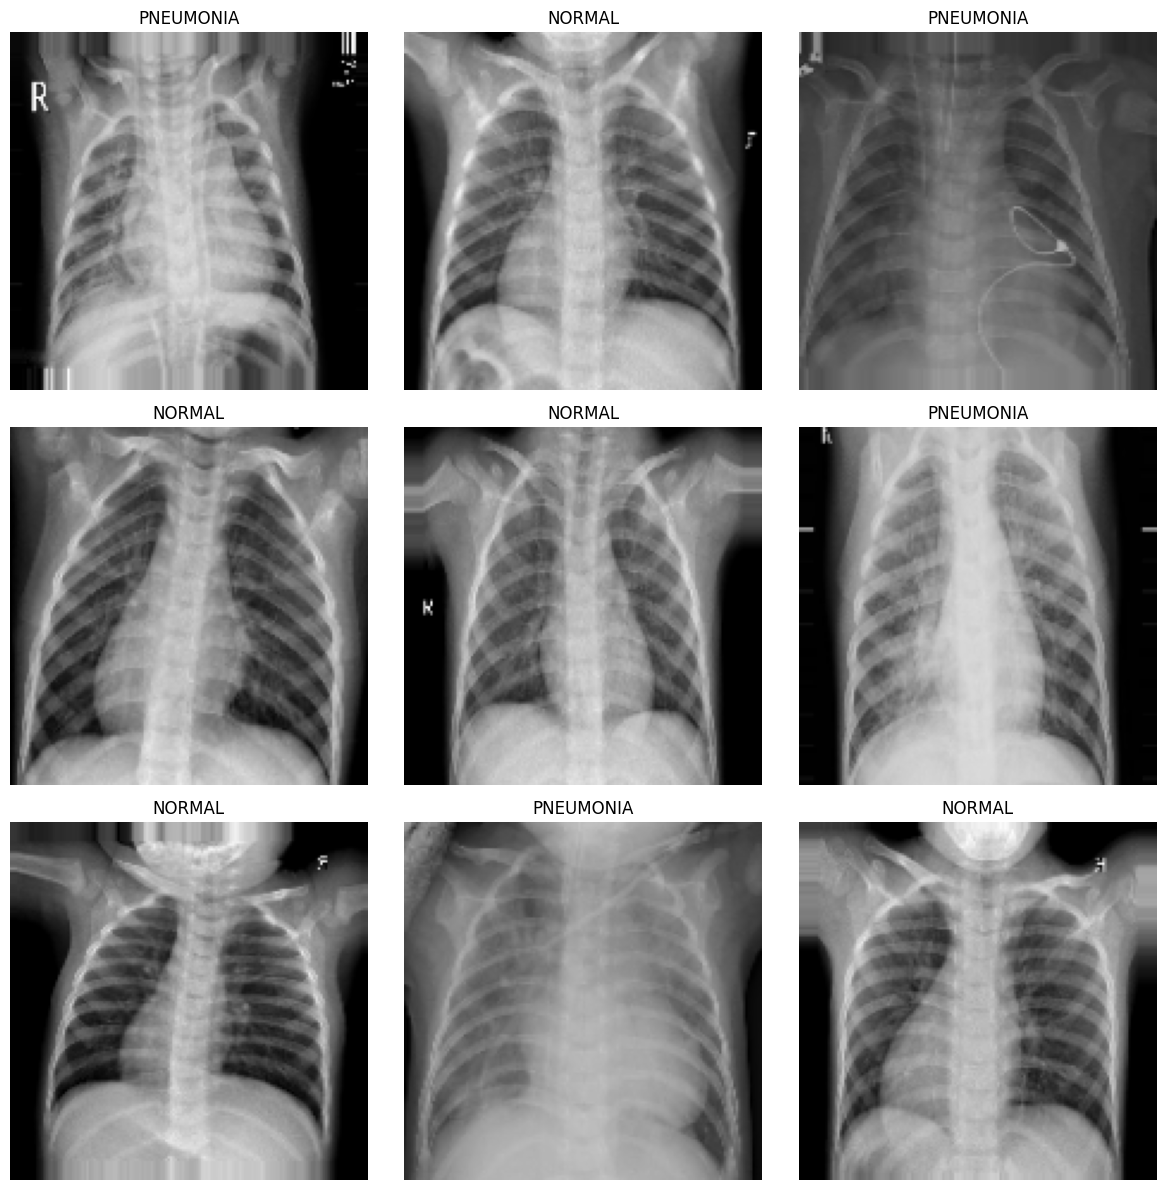

In [5]:
images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i] == 1 else "NORMAL")
    plt.axis("off")

plt.tight_layout()
plt.show()

Now, let's define the CNN model architecture. I'll use a simple sequential model with `Conv2D`, `MaxPooling2D`, `Flatten`, and `Dense` layers.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

Next, we compile the model using the Adam optimizer and binary cross-entropy loss, which is suitable for binary classification tasks.

In [7]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

Now, let's train the model using the prepared data generators.

In [9]:
EPOCHS = 4

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

Epoch 1/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.8528 - loss: 0.3310 - val_accuracy: 0.6875 - val_loss: 0.9129
Epoch 2/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.9181 - loss: 0.2033 - val_accuracy: 0.7500 - val_loss: 0.5514
Epoch 3/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.9164 - loss: 0.2053 - val_accuracy: 0.8125 - val_loss: 0.3124
Epoch 4/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - accuracy: 0.9354 - loss: 0.1691 - val_accuracy: 0.8750 - val_loss: 0.4432


Finally, let's evaluate the model's performance on the test set.

In [10]:
loss, accuracy = model.evaluate(test_generator,
                                steps=test_generator.samples // BATCH_SIZE)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 800ms/step - accuracy: 0.8799 - loss: 0.3255
Test Loss: 0.3255
Test Accuracy: 0.8799


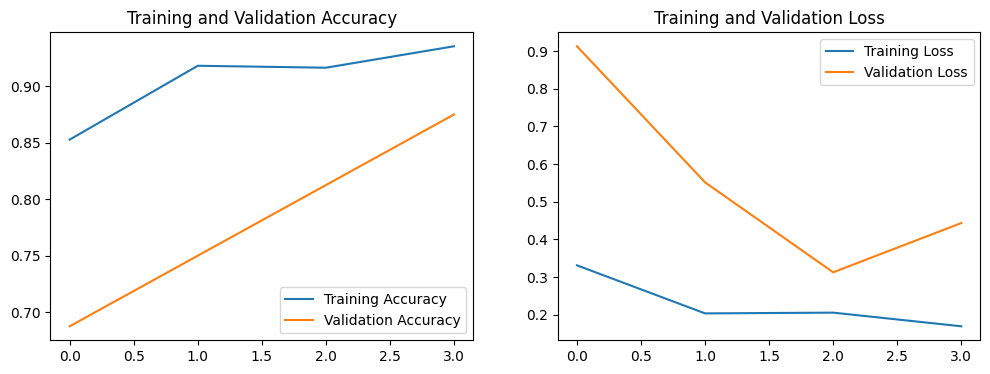

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels
true_classes = test_generator.classes

# Get predictions
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["NORMAL","PNEUMONIA"]
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 878ms/step
              precision    recall  f1-score   support

      NORMAL       0.40      0.30      0.34       234
   PNEUMONIA       0.64      0.73      0.68       390

    accuracy                           0.57       624
   macro avg       0.52      0.52      0.51       624
weighted avg       0.55      0.57      0.55       624



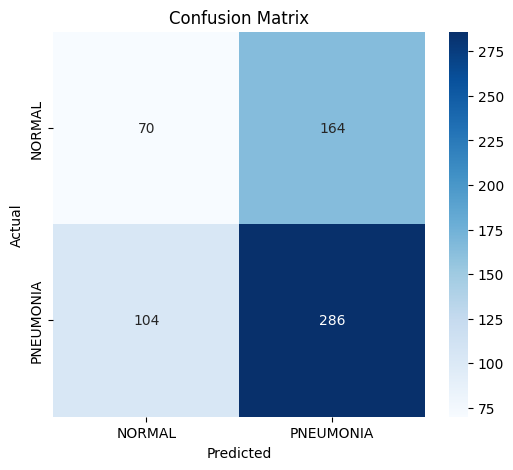

In [16]:
import seaborn as sns
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["NORMAL","PNEUMONIA"],
    yticklabels=["NORMAL","PNEUMONIA"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Prediction : PNEUMONIA


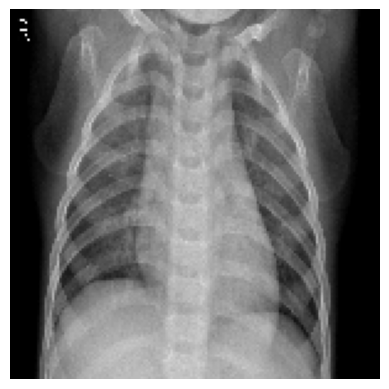

In [18]:
from tensorflow.keras.preprocessing import image
import numpy as np

sample_image = os.path.join(test_dir, "NORMAL", os.listdir(os.path.join(test_dir, "NORMAL"))[0])

img = image.load_img(sample_image, target_size=(150,150))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis("off")

if prediction[0][0] > 0.5:
    print("Prediction : PNEUMONIA")
else:
    print("Prediction : NORMAL")

In [19]:
model.save("Pneumonia_CNN_Model.keras")

print("Model saved successfully!")

Model saved successfully!
